In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("../data/results.csv")
df.head()

,Unnamed: 0,Age,LogAmount,AmountZScore,MovingAvg,MovingStd,LogTimeDiff,Hoursin,Hourcos,TransactionTypeEntropy,...,CityEntropy,TransactionTypeFreq,ChannelFreq,CardTypeFreq,MerchandFreq,CountryFreq,CityFreq,isoscores,aescores,somscores
0,0,29,-0.360200,0.0,0.0,0.0,0.000000,-1.272564,-0.412952,-1.110223e-10,...,0.0,1.797384,8.720711,5.693683,9.919398,0.0,0.737762,0.867007,0.070413,0.434761
1,1,29,1.805663,0.0,0.0,0.0,0.078768,-0.604747,1.160894,-1.110223e-10,...,0.0,1.797384,2.702942,1.211596,4.091762,0.0,-1.029117,0.670941,0.136119,0.251699
2,2,29,-0.145561,0.0,0.0,0.0,-0.024697,1.125414,0.938540,-1.110223e-10,...,0.0,-1.366136,0.697018,2.705625,6.034307,0.0,-0.440157,0.550379,0.296831,0.228877
3,3,29,-0.397814,0.0,0.0,0.0,0.672494,-0.604747,-1.262535,-1.110223e-10,...,0.0,0.611064,2.702942,3.452639,1.177945,0.0,-0.145677,0.451894,0.110281,0.247304
4,4,29,-1.028916,0.0,0.0,0.0,0.658675,0.482878,1.300671,-1.110223e-10,...,0.0,0.848328,-0.907720,3.900848,0.595181,0.0,0.031011,0.336467,0.294720,0.165296


In [3]:
df.shape

(220802, 24)

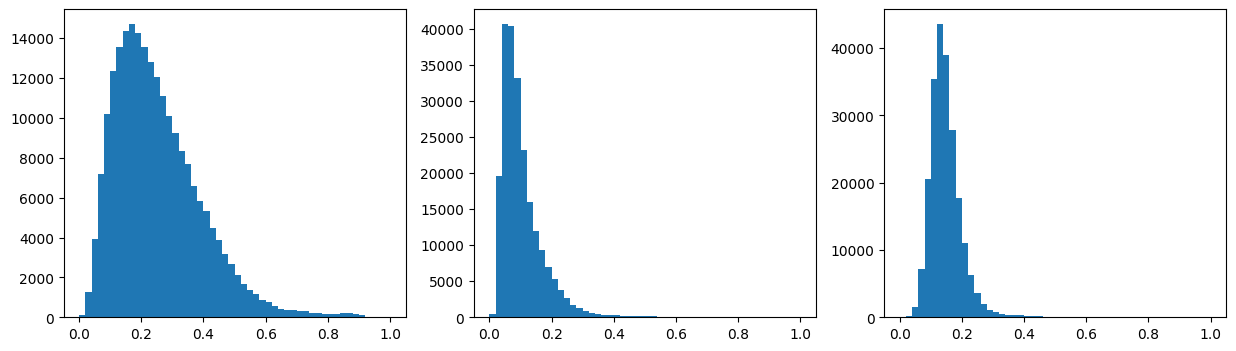

In [4]:
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(15,4))

axes[0].hist(df['isoscores'],bins=50)
axes[1].hist(df['aescores'],bins=50)
axes[2].hist(df['somscores'],bins=50)

plt.show()

In [5]:
corr=df[['isoscores','somscores','aescores']].corr(method='spearman')
corr

,isoscores,somscores,aescores
isoscores,1.000000,0.708089,0.735111
somscores,0.708089,1.000000,0.639742
aescores,0.735111,0.639742,1.000000


In [20]:
topscores=int(df.shape[0]*0.01)
isoresult=df.sort_values(by='isoscores',ascending=False).iloc[:topscores]
somresult=df.sort_values(by='somscores',ascending=False).iloc[:topscores]
aeresult=df.sort_values(by='aescores',ascending=False).iloc[:topscores]

overlap=len(set(isoresult.index)&set(aeresult.index)&set(somresult.index))/topscores
overlap*100

18.61413043478261

In [7]:
from scipy.stats import rankdata

def rank_normalize_df(df_scores):
    return df_scores.apply(lambda col: rankdata(col) / len(col))

In [8]:
def top_k_idx(series, k=0.01):
    n = len(series)
    k = int(n * k)
    return set(series.nlargest(k).index)

In [9]:
def top_k_overlap(df, col1, col2, k=0.01):
    top1 = top_k_idx(df[col1], k)
    top2 = top_k_idx(df[col2], k)
    return len(top1 & top2) / len(top1)

In [10]:
def overlap_matrix(df, cols, k=0.01):
    result = {}

    for c1 in cols:
        result[c1] = {}
        for c2 in cols:
            result[c1][c2] = top_k_overlap(df, c1, c2, k)

    return result

In [11]:
dfranked=rank_normalize_df(df)

In [12]:
cols = ['isoscores','somscores','aescores']
overlap=overlap_matrix(dfranked,cols)
overlap

{'isoscores': {'isoscores': 1.0,
  'somscores': 0.697463768115942,
  'aescores': 0.33106884057971014},
 'somscores': {'isoscores': 0.697463768115942,
  'somscores': 1.0,
  'aescores': 0.3070652173913043},
 'aescores': {'isoscores': 0.33106884057971014,
  'somscores': 0.3070652173913043,
  'aescores': 1.0}}